In [1]:
# import standard packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
from pathlib import Path
import dask.dataframe as dd
import cmocean
import xesmf as xe
import seaborn as sns
# import spatial packages
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rio
import seaborn as sns
import xarray as xr
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from dask.distributed import Client
from google.cloud import storage
import xskillscore as xs

# import statistical packages
from scipy.stats import linregress, pearsonr
from shapely.geometry import Point, mapping
from sklearn.metrics import mean_squared_error

try:
    import flox
except ImportError:
    print("[ACTEA_downscale] Warning: flox not installed - continuing without")

import sys
sys.path.append('../')
import ACTEA_gcs
import ACTEA_merge_datasets
gcs = ACTEA_gcs.ACTEA_gcs("monthly")
gcs.setup_actea_google_storage()

In [2]:
# Settings for the script
sns.set_style("white")
depth = 5.0
actea_variables = ["uo","vo"]
time="2018-01-01"
coarsen_step = 1
lat_lon_ext = [360-173., 360-154., 54., 68.]

base_path=f"mCDR_validation/{int(depth)}"
if not Path(base_path).exists():
    Path(base_path).mkdir(parents=True)

### Load the Ba+SD downscaled GLORYS12V1 data
Load the final dataset after downscaling the coarsened GLORYS12V1 dataset.

In [3]:
ds_all_actea={}
for varname, iterations in zip(actea_variables, [0,0]):
    ds_all_actea[varname], ds_plotfile = ACTEA_merge_datasets.create_merged_ds(["test_glorys"], 
                                                            "GLORYS12V1",  
                                                            "surface", 
                                                            varname, 
                                                            "ssp585", 
                                                            "r1i1p1f1", 
                                                            depth,
                                                            iterations=iterations)
    print(f"ACTEA: {varname} dataset size in MB", ds_all_actea[varname][varname].size / (1024*1024))
    
ds_uo_actea = ds_all_actea["uo"].assign_coords(lon=(np.mod(ds_all_actea["uo"].lon, 360))).sortby("lon")
ds_vo_actea = ds_all_actea["vo"].assign_coords(lon=(np.mod(ds_all_actea["vo"].lon, 360))).sortby("lon")

ds_uo_actea = ds_uo_actea.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))
ds_vo_actea = ds_vo_actea.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))


[ACTEA_merge_datasets] ssp585 uo (324, 217, 337)
ACTEA: uo dataset size in MB 22.59616470336914
[ACTEA_merge_datasets] ssp585 vo (324, 217, 337)
ACTEA: vo dataset size in MB 22.59616470336914


In [4]:
import matplotlib.colors as mcolors
def plot_map_glorys_or_actea_on_standard_grid(varname, da: xr.DataArray, 
                                            lat_lon_ext, year="2015-2020", 
                                            producer="ACTEA", vmin=-0.2, vmax=0.2):
    
    fig = plt.figure(figsize=[18,4])
    ax = fig.add_subplot(projection= ccrs.PlateCarree(central_longitude=0),facecolor='ghostwhite')
    da.plot(y='lat',x='lon', 
                            ax=ax,
                vmin=vmin, vmax=vmax, extend='both',
                cmap=cmocean.cm.balance, add_colorbar=True)

    land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                            edgecolor='face',
                                            facecolor='ghostwhite')

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Customize the gridlines and tick labels
    gl.top_labels = False      # Changed from gl.xlabels_top
    gl.right_labels = False    # Changed from gl.ylabels_right
    gl.left_labels = True      # Add this for consistency
    gl.bottom_labels = True    # Add this for consistency
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    ax.coastlines()
  #  ax.add_feature(land_10m)
  #  ax.add_feature(cfeature.COASTLINE)
    ax.gridlines(color='black', alpha=0.5, linestyle='--')
    ax.set_extent(lat_lon_ext, crs=ccrs.PlateCarree())
    #plt.title(f"{producer} grid {varname} 2015-2020")
    plt.savefig(f"{base_path}/{producer}_{varname}_2015-2020.png", dpi=200, bbox_inches='tight', facecolor='w')
    plt.show()

### Load the original GLORYS dataset
This dataset is stored from 1993 to 2019. The dataset is stored in the form of a netCDF file. The dataset
is generated and upload to GCS automatically when you run the downscaling using ´GLORYS12V1´ as the model. This dataset is
then coarsened and used as the input for the downscaling process. 

In [5]:
def load_glorys_datasets():
    ds_uo = gcs.open_dataset_on_gs(f"downscaling/test_glorys/ssp585/GLORYS12V1/uo/GLORYS12V1_r1i1p1f1_uo_surface_{depth}_{depth}m_GLORYS12V1_full.nc", engine="h5netcdf")
    ds_vo = gcs.open_dataset_on_gs(f"downscaling/test_glorys/ssp585/GLORYS12V1/vo/GLORYS12V1_r1i1p1f1_vo_surface_{depth}_{depth}m_GLORYS12V1_full.nc", engine="h5netcdf")
    ds_uo = ds_uo.assign_coords(lon=(np.mod(ds_uo.lon, 360))).sortby("lon")
    ds_vo = ds_vo.assign_coords(lon=(np.mod(ds_vo.lon, 360))).sortby("lon")
  
    return ds_uo.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])), ds_vo.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))

ds_uo_glorys, ds_vo_glorys = load_glorys_datasets()

print("GLORYS fine uo size in MB", ds_uo_glorys.uo.size / (1024*1024))
print("GLORYS fine vo size in MB", ds_vo_glorys.vo.size / (1024*1024))
#print(f"Time range: {ds_uo_glorys.time.min().values} to {ds_uo_glorys.time.max().values()}")

GLORYS fine uo size in MB 11.958240509033203
GLORYS fine vo size in MB 11.958240509033203


In [6]:
def load_coarsened_glorys_datasets():
    ds_uo_coarse = gcs.open_dataset_on_gs(f"downscaling/test_glorys/ssp585/GLORYS12V1/uo/GLORYS12V1_r1i1p1f1_uo_surface_{depth}_{depth}m_GLORYS12V1_coarsened_step_12.nc", engine="h5netcdf")
    ds_vo_coarse = gcs.open_dataset_on_gs(f"downscaling/test_glorys/ssp585/GLORYS12V1/vo/GLORYS12V1_r1i1p1f1_vo_surface_{depth}_{depth}m_GLORYS12V1_coarsened_step_12.nc", engine="h5netcdf")
    return ds_uo_coarse, ds_vo_coarse

ds_uo_coarse, ds_vo_coarse = load_coarsened_glorys_datasets()
ds_uo_coarse = ds_uo_coarse.assign_coords(lon=(np.mod(ds_uo_coarse.lon, 360))).sortby("lon")
ds_vo_coarse = ds_vo_coarse.assign_coords(lon=(np.mod(ds_vo_coarse.lon, 360))).sortby("lon")

ds_uo_coarse = ds_uo_coarse.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))
ds_vo_coarse = ds_vo_coarse.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))

print("GLORYS coarse uo size in MB", ds_uo_coarse.uo.size / (1024*1024))
print("GLORYS coarse vo size in MB", ds_vo_coarse.vo.size / (1024*1024))
print(f"Time range: {ds_uo_coarse.time.min().values} to {ds_uo_coarse.time.max().values}")

GLORYS coarse uo size in MB 0.0926971435546875
GLORYS coarse vo size in MB 0.0926971435546875
Time range: 1993-01-16T12:00:00.000000000 to 2019-12-16T12:00:00.000000000


In [7]:
ds_vo_coarse=ds_vo_coarse.sel(time=slice("2015-01-01","2021-01-01")).chunk({"time":-1, "lat":-1, "lon": -1})
ds_uo_coarse= ds_uo_coarse.sel(time=slice("2015-01-01","2021-01-01")).chunk({"time":-1, "lat":-1, "lon": -1})
ds_uo_coarse = ds_uo_coarse.resample(time="1M").mean()
ds_vo_coarse = ds_vo_coarse.resample(time="1M").mean()

/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


### Plot the datasets to see the original data
We plot the úo´and ´vo´ variables to see the original data.

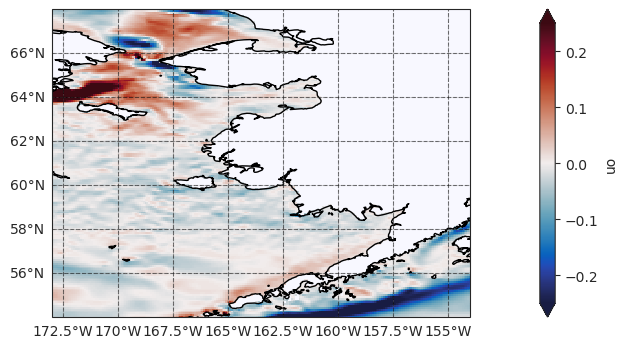

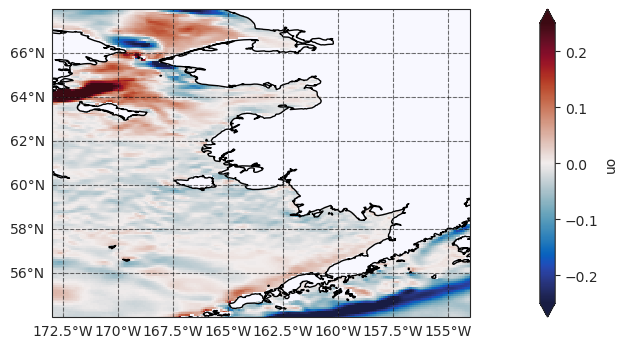

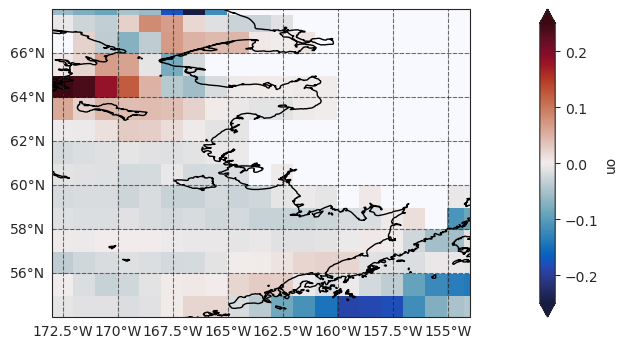

In [ ]:

# u velocity
for varname, ds, name in zip(["uo","uo", "uo"], [ds_uo_glorys, ds_uo_actea, ds_uo_coarse], ["GLORYS", "ACTEA", "COARSE"]):
   plot_map_glorys_or_actea_on_standard_grid(varname,  ds[varname].sel(time=slice("2015-01-01","2020-01-01")).mean(dim="time"), 
                                             lat_lon_ext, year="2015_2020", producer=name, vmin=-0.25, vmax=0.25)

# v velocity
for varname, ds, name in zip(["vo","vo", "vo"], [ds_vo_glorys, ds_vo_actea, ds_vo_coarse], ["GLORYS", "ACTEA", "COARSE"]):
   plot_map_glorys_or_actea_on_standard_grid(varname,  ds[varname].sel(time=slice("2015-01-01","2020-01-01")).mean(dim="time"), 
                                             lat_lon_ext, year="2015_2020", producer=name, vmin=-0.25, vmax=0.25)

# Speed
for varname_u, ds_u, varname_v, ds_v, name in zip(["uo","uo", "uo"], [ds_uo_glorys, ds_uo_actea, ds_uo_coarse],
                                                  ["vo","vo", "vo"], [ds_vo_glorys, ds_vo_actea, ds_vo_coarse],
                                                  ["GLORYS", "ACTEA", "COARSE"]):
   speed = np.sqrt(ds_u[varname_u]**2 + ds_v[varname_v]**2).sel(time=slice("2015-01-01","2020-01-01")).mean(dim="time")
   plot_map_glorys_or_actea_on_standard_grid("speed",  speed, lat_lon_ext, year="2015_2020", producer=name, vmin=0.0, vmax=0.25)

In [ ]:
# uo
ds_uo_glorys=ds_uo_glorys.sel(time=slice("2015-01-01","2021-01-01")).chunk({"time":-1, "lat":-1, "lon": -1})
ds_uo_actea= ds_uo_actea.sel(time=slice("2015-01-01","2021-01-01")).chunk({"time":-1, "lat":-1, "lon": -1})
ds_uo_glorys = ds_uo_glorys.resample(time="1M").mean()
ds_uo_actea = ds_uo_actea.resample(time="1M").mean()

# vo
ds_vo_glorys=ds_vo_glorys.sel(time=slice("2015-01-01","2021-01-01")).chunk({"time":-1, "lat":-1, "lon": -1})
ds_vo_actea= ds_vo_actea.sel(time=slice("2015-01-01","2021-01-01")).chunk({"time":-1, "lat":-1, "lon": -1})
ds_vo_glorys = ds_vo_glorys.resample(time="1M").mean()
ds_vo_actea = ds_vo_actea.resample(time="1M").mean()

/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


### Weight according to latitude and calculate speed
We use scalar speed as our correlation metric.

In [ ]:
# make weights as cosine of the latitude and broadcast
weights = np.cos(np.deg2rad(ds_vo_actea.lat))

ds_glorys_speed=np.sqrt(ds_uo_glorys.uo**2 + ds_vo_glorys.vo**2)
ds_actea_speed=np.sqrt(ds_uo_actea.uo**2 + ds_vo_actea.vo**2)

ds_glorys_speed_coarse = ds_glorys_speed.coarsen(lat=coarsen_step, lon=coarsen_step, boundary="pad").mean()
ds_actea_speed_coarse = ds_actea_speed.coarsen(lat=coarsen_step, lon=coarsen_step, boundary="pad").mean()

#r = xs.pearson_r(ds_glorys_speed_coarse, ds_actea_speed_coarse, dim=["time"], skipna=True)

#print("Pearson correlation velocity - coarse", r.mean().values)
#r.plot(vmin=0, vmax=1.0)
#plt.savefig(f"{base_path}/pearson_r_speed_coarse_2015_2020.png", dpi=200, bbox_inches='tight')

Pearson correlation speed - fine 0.7453651998899542


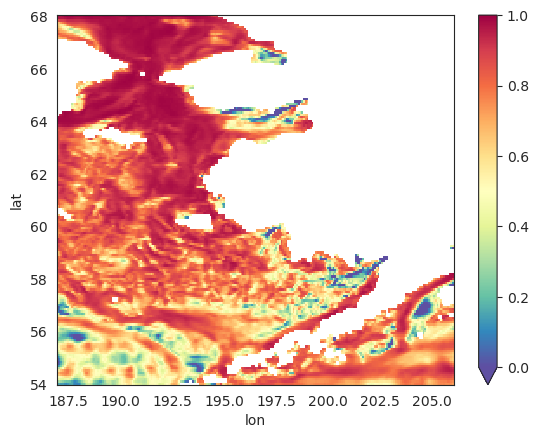

In [ ]:
r = xs.pearson_r(ds_glorys_speed, ds_actea_speed, dim=["time"], skipna=True)
print("Pearson correlation speed - fine", r.mean().values)
r.plot(vmin=0, vmax=1.0, cmap="Spectral_r")
plt.savefig(f"{base_path}/pearson_r_speed_fine_2015_2020.png", dpi=200, bbox_inches='tight')

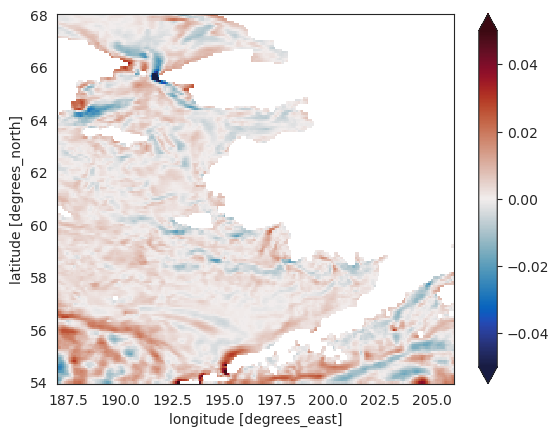

In [ ]:
(ds_actea_speed.mean("time")-ds_glorys_speed.mean("time")).plot(vmin=-0.05, vmax=0.05, cmap=cmocean.cm.balance)
plt.savefig(f"{base_path}/diff_sa_actea_speed_vs_ds_glorys_speed_coarse_2015_2020.png")

RMSE velocity - fine 0.023737599949696 of mean 0.08140711819216391


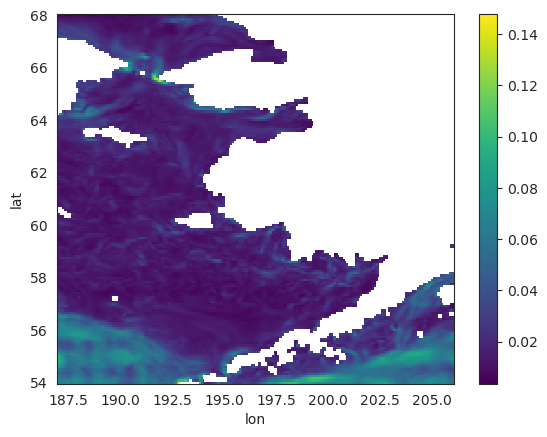

In [ ]:
r = xs.rmse(ds_actea_speed, ds_glorys_speed, dim=["time"], skipna=True)
print(f"RMSE velocity - fine {r.mean().values} of mean {ds_actea_speed.mean().values}")
r.plot()
plt.savefig(f"{base_path}/rmse_speed_2015_2020.png", dpi=200, bbox_inches='tight')

### Calculate the Liu-mean efficiency score

• LSE: calculated alpha 0.9999547304765951
• LSE: calculated beta: 0.9999523564230461
• LSE: calculated rho: 0.8145382346202374
• LSE: calculated LSE: 0.8145077461952652


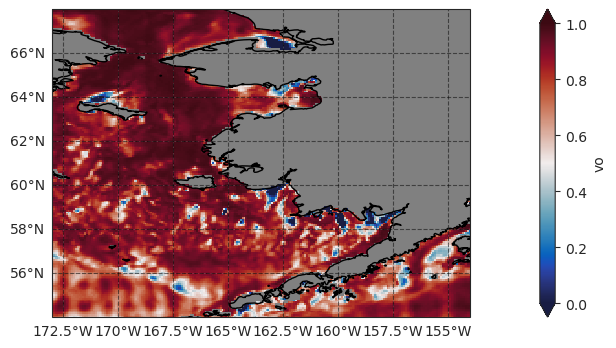

Average Liu-mean skill score VO: 0.8145077461952652
• LSE: calculated alpha 0.9999800000222697
• LSE: calculated beta: 0.9999239136490687
• LSE: calculated rho: 0.7528267196008483
• LSE: calculated LSE: 0.7528162903315773


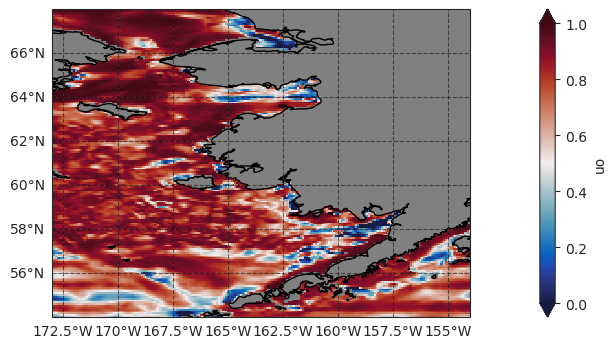

Average Liu-mean skill score UO: 0.7528162903315773
• LSE: calculated alpha 0.9999405191608969
• LSE: calculated beta: 0.9999948731989899
• LSE: calculated rho: 0.7453651998899542


KeyboardInterrupt: 

In [ ]:
def liu_mean_efficiency_skill_score(ds_actea_speed_coarse, ds_glorys_speed_coarse):
    """
    Liu-mean efficiency skill  score (LSE)
    • The ratio of the model mean over the mean of observations (alpha) which assessed the overall bias of the model  fields for each season;
    • The ratio of the model standard deviation over the standard deviation of observations (beta) which assessed the  overall spread of the model fields for each season;
    • The Pearson correlation coefficient (rho) of the spatial fields from the model and from the observations which  estimated the spatial mismatch of local features and bias.  
    
    A Liu skill score of 1 represents a perfect comparison with observations, while values below 1 indicate a  diminishing level of comparison between ensemble and observations. 
    """               
    ds_actea_speed_coarse_filtered = ds_actea_speed_coarse.where(ds_glorys_speed_coarse.notnull())
    ds_glorys_speed_coarse_filtered = ds_glorys_speed_coarse.where(ds_actea_speed_coarse_filtered.notnull())
    
    # Calculate spatial means
    mean_actea = ds_actea_speed_coarse_filtered.mean(dim="time", skipna=True)
    mean_glorys = ds_glorys_speed_coarse_filtered.mean(dim="time", skipna=True)
    epsilon = 30

    alpha = (mean_actea + epsilon) / (mean_glorys + epsilon)
    
    std_actea = ds_actea_speed_coarse_filtered.std(dim="time", skipna=True)
    std_glorys = ds_glorys_speed_coarse_filtered.std(dim="time", skipna=True)
    beta = (std_actea + epsilon) / (std_glorys + epsilon)
        
    rho = xs.pearson_r(ds_glorys_speed_coarse_filtered, ds_actea_speed_coarse_filtered, dim=["time"], skipna=True)
    LSE = 1.0 - np.sqrt((rho*alpha - 1.0)**2 + (beta - 1.0)**2)
 
    return LSE

LSE = liu_mean_efficiency_skill_score(ds_vo_glorys.vo, ds_vo_actea.vo)
plot_map_glorys_or_actea_on_standard_grid("LSE_vo", LSE, lat_lon_ext, year=2015, producer="ACTEA", vmin=0.0, vmax=1.0)
print(f"Average Liu-mean skill score VO: {LSE.mean().values}")

LSE = liu_mean_efficiency_skill_score(ds_uo_glorys.uo, ds_uo_actea.uo)
plot_map_glorys_or_actea_on_standard_grid("LSE_uo", LSE, lat_lon_ext, year=2015, producer="ACTEA", vmin=0.0, vmax=1.0)
print(f"Average Liu-mean skill score UO: {LSE.mean().values}")

LSE = liu_mean_efficiency_skill_score(ds_glorys_speed, ds_actea_speed)
plot_map_glorys_or_actea_on_standard_grid("LSE_speed", LSE, lat_lon_ext, year=2015, producer="ACTEA", vmin=0.0, vmax=1.0)
print(f"Average Liu-mean skill score SPEED: {LSE.mean().values}")


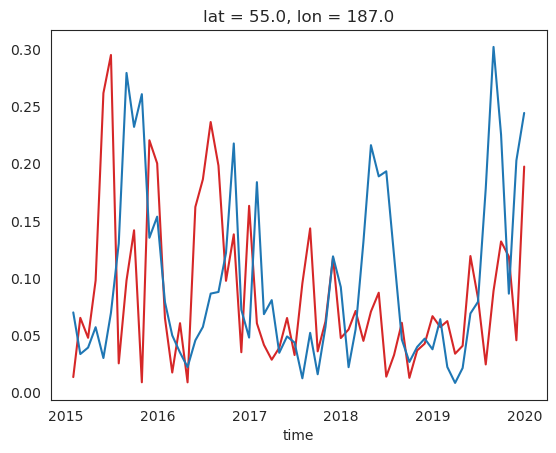

In [ ]:
ds_actea_speed.sel(lat=55, lon=-167, method="nearest").plot(color="tab:red")
ds_glorys_speed.sel(lat=55, lon=-167, method="nearest").plot(color="tab:blue")
plt.savefig(f"{base_path}/timeseries_speed_fine_2015_2020.png", dpi=200, bbox_inches='tight')